In [ ]:
import torch
import torch.optim as optim
from torchviz import make_dot
import pandas as pd
from itables import init_notebook_mode, show
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import importlib
from tqdm import tqdm

import gradual_aacbr
import semantics.mlp_semantics as ms
import base_scores.feature_weighted_base_score as fwbs
import casebase_edge_weights.feature_weighted_partial_order as fwpo
import irrelevance_edge_weights.feature_weighted_irrelevance as fwi

init_notebook_mode(all_interactive=True)

In [ ]:
def reload_imports():
    importlib.reload(gradual_aacbr)
    importlib.reload(ms)
    importlib.reload(fwbs)
    importlib.reload(fwpo)
    importlib.reload(fwi)

reload_imports()

## Gradual AACBR

In [ ]:
reload_imports()
X_train = torch.tensor([
    [1], # 0
    [3], # 1
], dtype=torch.float32)

y_train = torch.tensor([0, 0], dtype=torch.float32)

X_default = torch.tensor([
        [0]
], dtype=torch.float32) # 2
y_default = torch.tensor([1], dtype=torch.float32)

torch.manual_seed(0)

no_features = X_train.shape[-1]
semantics = ms.MLPBasedSemantics(max_iters=5, epsilon=0)
model = gradual_aacbr.GradualAACBR(semantics, 
                                   fwbs.FeatureWeightedBaseScore(no_features), 
                                   fwi.FeatureWeightedIrrelevance(no_features), 
                                   fwpo.FeatureWeightedPartialOrder(no_features))

model.fit(X_train, y_train, X_default, y_default)

new_case = torch.tensor([
    [2],
], dtype=torch.float32)

strengths = model(new_case)
print(strengths)

model.show_matrix()
model.show_graph_with_labels()



## Data Set

In [ ]:
SEED = 42

In [ ]:
# from ucimlrepo import fetch_ucirepo 
  
# # fetch dataset 
# connectionist_bench_sonar_mines_vs_rocks = fetch_ucirepo(id=151) 
  
# # data (as pandas dataframes) 
# X = connectionist_bench_sonar_mines_vs_rocks.data.features 
# y = connectionist_bench_sonar_mines_vs_rocks.data.targets 

data = pd.read_csv('data/connectionist-bench-sonar-mines-vs-rocks/sonar.all-data')

data = data.values

X = np.array(data[:, :-1], dtype=np.float32)
y = np.array(data[:, -1])

show(X)
print(np.unique(y))



In [ ]:
encoder = LabelEncoder()
encoder.fit(y)
y = encoder.transform(y)


## Train Model

### Split into Training, Validation and Test

In [54]:
X, y = torch.tensor(X), torch.tensor(y, dtype=torch.float32)
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=SEED)
print(f"Test Size:  {len(X_test)}")
print(f"Train Size:  {len(X_train)}")
print(f"Validation Size:  {len(X_val)}")

Test Size:  42
Train Size:  132
Validation Size:  33


In [55]:
print(X_train)

tensor([[0.0176, 0.0172, 0.0501,  ..., 0.0179, 0.0294, 0.0063],
        [0.0195, 0.0142, 0.0181,  ..., 0.0042, 0.0067, 0.0012],
        [0.0294, 0.0123, 0.0117,  ..., 0.0006, 0.0081, 0.0043],
        ...,
        [0.0423, 0.0321, 0.0709,  ..., 0.0021, 0.0043, 0.0017],
        [0.0409, 0.0421, 0.0573,  ..., 0.0061, 0.0030, 0.0078],
        [0.0132, 0.0080, 0.0188,  ..., 0.0140, 0.0028, 0.0064]])


### Build AF

In [56]:
# TODO: Consider more sophisticated orders

# Compare against the average for each column
means = X_train.mean(axis=0)
std = X_train.std(axis=0)

STD_PARAM = 2

def binarise_by_normal(case):
    return np.where(np.abs(case - means) <= STD_PARAM*std, 0, 1)


In [57]:
PREPROCESS_FUNC = binarise_by_normal 

### Train Model

In [94]:
DEFAULT_OUTCOME = 1
DEFAULT_CASE = means

X_DEFAULTS = DEFAULT_CASE.unsqueeze(0)
Y_DEFAULTS = torch.tensor([DEFAULT_OUTCOME])

MAX_ITERS = 20 
EPOCHS = 25 
N_SPLITS = 5
USE_SYMMETRIC_ATTACKS = True

In [95]:
reload_imports()

def run_gradual_model(model: gradual_aacbr.GradualAACBR, X_train, y_train, X_default, 
                      y_default, new_cases):

    model.fit(X_train, y_train, X_default, y_default, USE_SYMMETRIC_ATTACKS)
    return model(new_cases)


def evaluate_model(model, X_train, y_train, X_default, y_default, new_cases, new_cases_labels,
                   show_confusion=False, print_graph=False, print_matrix=False, print_compute_graph = False):


    final_stengths = run_gradual_model(model, X_train, y_train, X_default, y_default, new_cases)
    predicted = final_stengths.cpu().detach().numpy()
    predicted = np.where(predicted > 0.5, 1, 0)

    print("Accuracy, Precision, Recall, F1")
    print([
        accuracy_score(new_cases_labels, predicted),
        precision_score(new_cases_labels, predicted, average='macro'),
        recall_score(new_cases_labels, predicted, average='macro'),
        f1_score(new_cases_labels, predicted, average='macro')
    ])


    if show_confusion:
        cm = confusion_matrix(new_cases_labels, predicted)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot()
        plt.show()

    if print_graph:
        model.show_graph_with_labels()

    if print_matrix:
        model.show_matrix()

    if print_compute_graph:
        criterion = torch.nn.BCELoss()
        print((final_stengths.squeeze(), new_cases_labels))
        loss = criterion(final_stengths.squeeze(), new_cases_labels)
        make_dot(loss, params=dict(model.named_parameters())).render("gradual_aacbr", format="pdf")



In [96]:
reload_imports()
torch.manual_seed(0) # TRY DIFFERENT INITIAL WEIGHTS 
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

no_features = X_train.shape[-1]
semantics = ms.MLPBasedSemantics(max_iters=MAX_ITERS, epsilon=0)
model = gradual_aacbr.GradualAACBR(semantics, 
                                   fwbs.FeatureWeightedBaseScore(no_features), 
                                   fwi.FeatureWeightedIrrelevance(no_features), 
                                   fwpo.FeatureWeightedPartialOrder(no_features))

criterion = torch.nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9)

Accuracy, Precision, Recall, F1
[0.48484848484848486, 0.24242424242424243, 0.5, 0.32653061224489793]


/home/adam/Documents/dev/gradual-aacbr/gradual-aacbr/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


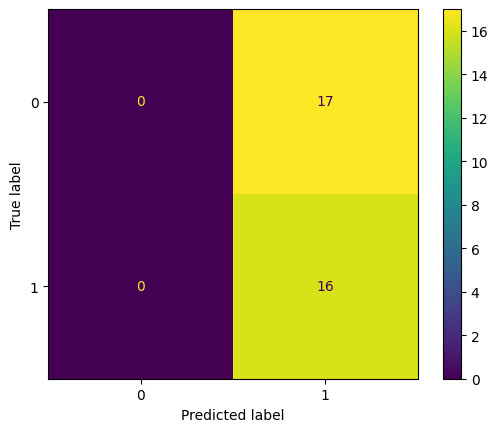

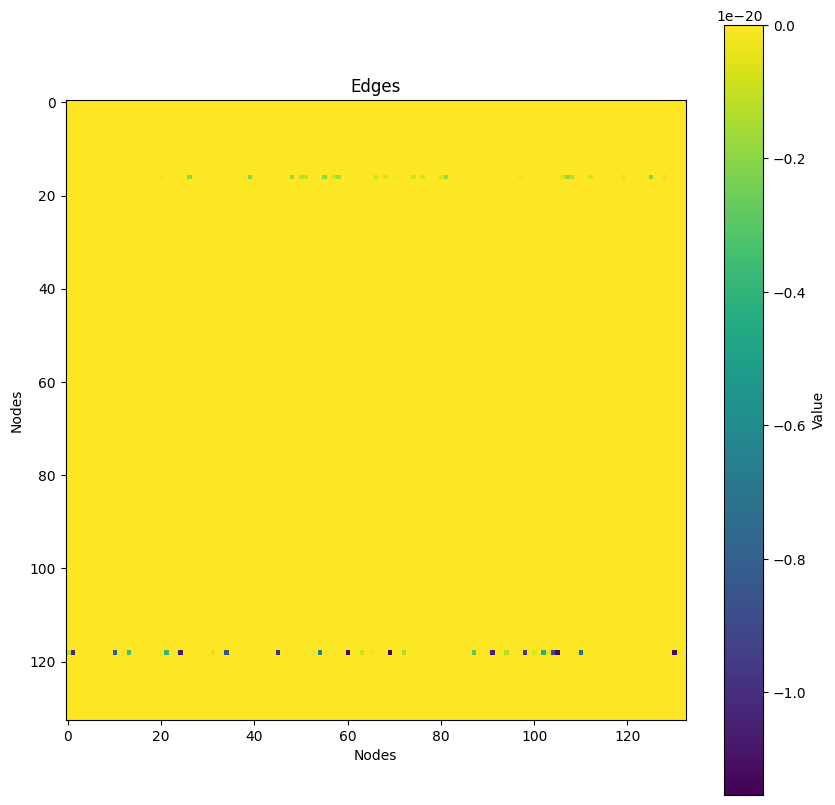

(tensor([0.9570, 0.9762, 0.9564, 0.9584, 0.9613, 0.9773, 0.9748, 0.9723, 0.9664,
        0.9747, 0.9754, 0.9543, 0.9522, 0.9687, 0.9606, 0.9713, 0.9708, 0.9664,
        0.9699, 0.9607, 0.9614, 0.9525, 0.9695, 0.9746, 0.9714, 0.9699, 0.9512,
        0.9644, 0.9579, 0.9597, 0.9517, 0.9686, 0.9691],
       grad_fn=<SqueezeBackward0>), tensor([1., 0., 1., 1., 1., 1., 0., 0., 0., 1., 0., 1., 0., 0., 1., 0., 0., 0.,
        1., 1., 1., 1., 1., 0., 0., 0., 1., 0., 1., 1., 0., 0., 0.]))


In [97]:
reload_imports()
# with torch.no_grad():
evaluate_model(model, X_train, y_train, X_DEFAULTS, Y_DEFAULTS, X_val, y_val, show_confusion=True, print_matrix=True, print_compute_graph=True  )

In [98]:

DISABLE_TQDM = False

Epoch 25, Loss: 0.0261: 100%|██████████| 25/25 [00:59<00:00,  2.39s/it]

Finished Training


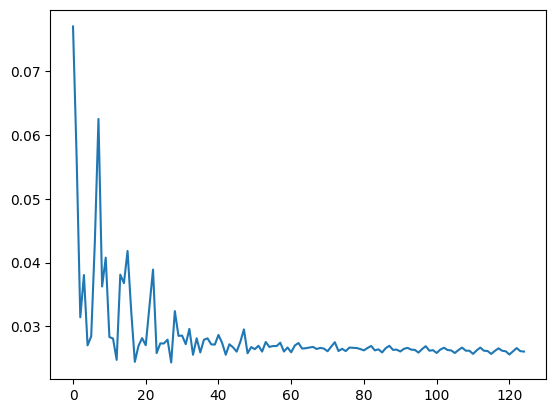

In [99]:
reload_imports()
losses = []
pbar = tqdm(range(EPOCHS), disable=DISABLE_TQDM)

for epoch in pbar:  
    for fold, (casebase_index,  new_cases_index) in enumerate(kf.split(X_train)):

        new_cases = X_train[new_cases_index]
        new_cases_labels = y_train[new_cases_index]

        casebase = X_train[casebase_index]
        casebase_labels = y_train[casebase_index]

        optimizer.zero_grad()

        # TODO: consider efficiency issues with having to rebuild each time 
        # Find a way to accumulate gradients update only when necessary?
        model.fit(casebase, casebase_labels, X_DEFAULTS, Y_DEFAULTS, USE_SYMMETRIC_ATTACKS)

        predictions = model(new_cases).squeeze()

        loss = criterion(predictions, new_cases_labels)
        loss.backward()

        optimizer.step()

        losses.append(loss.item()/len(new_cases))

    pbar.set_description(f'Epoch {epoch + 1}, Loss: {round(loss.item()/len(new_cases), 4)}')
    # make_dot(loss, params=dict(model.named_parameters())).render(f"aacbr_torch_fold{fold}_epoch{epoch}", format="pdf")






print('Finished Training')

plt.plot(losses)
plt.show()


Accuracy, Precision, Recall, F1
[0.36363636363636365, 0.36397058823529416, 0.36397058823529416, 0.36363636363636365]


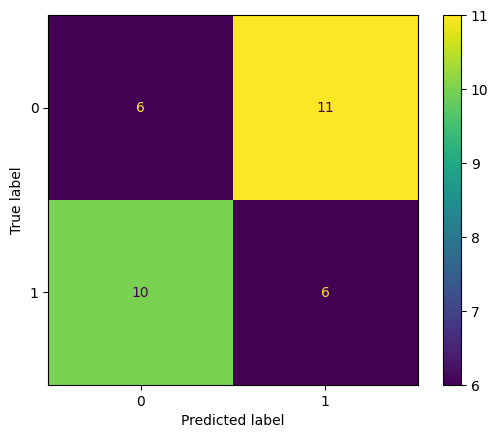

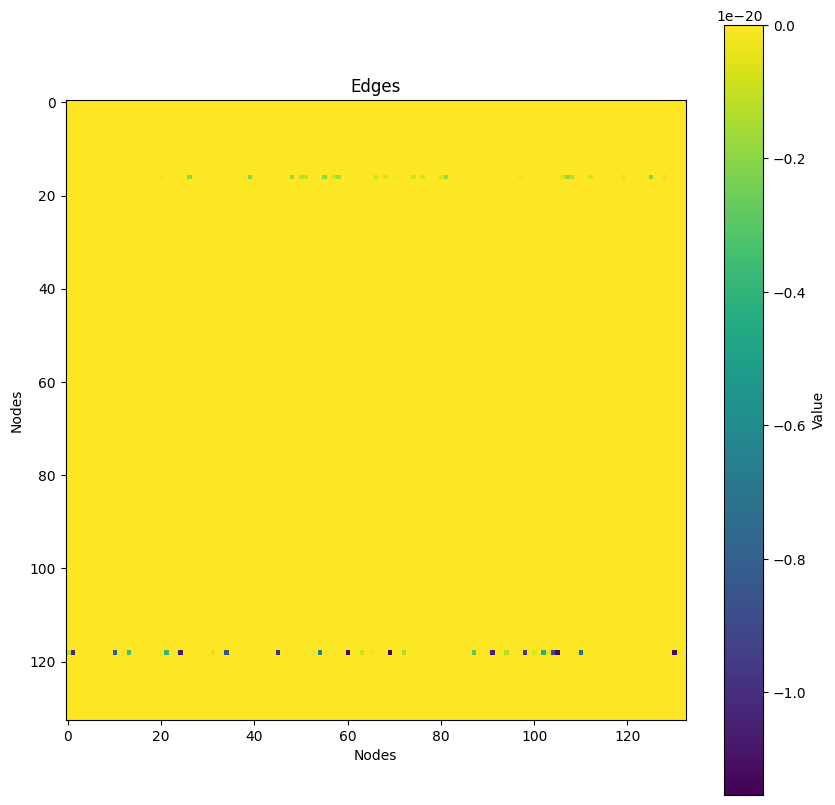

(tensor([0.4764, 0.5179, 0.4920, 0.5309, 0.4876, 0.4991, 0.5940, 0.5465, 0.4894,
        0.5054, 0.4735, 0.4568, 0.4846, 0.5546, 0.5302, 0.5839, 0.5242, 0.5009,
        0.4771, 0.4642, 0.5350, 0.4860, 0.5333, 0.5341, 0.5591, 0.5206, 0.4695,
        0.5230, 0.4982, 0.5569, 0.4759, 0.4743, 0.4880]), tensor([1., 0., 1., 1., 1., 1., 0., 0., 0., 1., 0., 1., 0., 0., 1., 0., 0., 0.,
        1., 1., 1., 1., 1., 0., 0., 0., 1., 0., 1., 1., 0., 0., 0.]))


In [100]:
reload_imports()
with torch.no_grad():
    evaluate_model(model, X_train, y_train, X_DEFAULTS, Y_DEFAULTS, X_val, y_val, show_confusion=True, print_matrix=True, print_compute_graph=True  )

### Test Set

In [101]:
# reload_imports()
# with torch.no_grad():
#     evaluate_model(X_train_full, y_train_full, X_test, y_test, show_confusion=True)